In [43]:
from collections import Counter
from dataclasses import field
from typing import Dict, List, Optional
import base64
import httpx
from io import BytesIO

from dotenv import load_dotenv
from langchain.agents import AgentState, create_agent
from langchain.chat_models import init_chat_model
from langchain.tools import ToolRuntime
from langchain_core.messages import HumanMessage, ToolMessage
from langchain.tools import tool
from langchain_tavily import TavilySearch
from langgraph.runtime import get_runtime
from langgraph.types import Command
from classifier import SCOLDClassifier
from detector import OWLv2Detector

load_dotenv()

True

In [44]:
model = init_chat_model("gemini-2.5-flash", model_provider="google_genai", temperature=0)

In [45]:
detector = OWLv2Detector(
    model_path="models/owlv2/owlv2.onnx",
    processor_path="models/owlv2",
    device="cpu"
)

classifier = SCOLDClassifier(
    model_path="models/scold/scold.onnx",
    collection_name="leaf_disease_collection"
)

In [46]:
class State(AgentState):
    image_url: Optional[str] = field(default=None)
    leaf_detections: List[Dict] = field(default_factory=list)
    leaf_disease_classifications: List[str] = field(default_factory=list)

In [47]:
@tool
async def leaf_detection(
    labels: List[str],
    threshold: float = 0.3,
    runtime: ToolRuntime[State] = None
) -> Command:
    """Detect and localize leaves in plant images using object detection.
    
    Identifies specific leaf types or objects in images based on text descriptions.
    Results are stored in state.leaf_detections and can be used by leaf_disease_identification
    for targeted region-based disease classification.
    
    Args:
        labels: Text descriptions for detection targets (e.g., ["diseased leaf", "healthy leaf"])
        threshold: Confidence threshold 0.0-1.0 for filtering detections (default: 0.3)
    
    Returns:
        Detection summary with counts, bounding boxes, and confidence scores per label
    """    

    image_url = runtime.state.get("image_url")
    if not image_url:
        raise ValueError("No plant image provided")

    async with httpx.AsyncClient() as client:
        response = await client.get(image_url)
        response.raise_for_status()
        image_binary = response.content

    detections = await detector.predict(
        image_input=image_binary,
        labels=labels,
        threshold=threshold,
    )

    label_counts = Counter(det["label"] for det in detections)

    summary = "Detection Summary:\n"
    for label, count in label_counts.items():
        summary += f"{label}: {count} detection(s)\n"

    summary += "\nDetailed Detections:\n"
    for det in detections:
        box = det["box"]
        summary += (
            f"{det['label']}: {det['score']:.3f} at "
            f"[{box[0]:.1f}, {box[1]:.1f}, {box[2]:.1f}, {box[3]:.1f}]\n"
        )

    return Command(
        update={
            "leaf_detections": detections,
            "messages": [
                ToolMessage(
                    summary,
                    tool_call_id=runtime.tool_call_id,
                )
            ],
        }
    )

@tool
async def leaf_disease_identification(
    query_text: Optional[str] = None,
    top_k: int = 5,
    method: str = "text-to-image",
    use_detections: bool = True,
    runtime: ToolRuntime[State] = None
) -> Command:
    """Identify plant diseases using multimodal classification with adaptive processing.
    
    Operates in two modes:
    1. Full-image mode: Analyzes entire image when no detections exist or use_detections=False
    2. Region-based mode: Processes each detected leaf region separately when state.leaf_detections 
       exists and use_detections=True, providing per-region disease classification
    
    Classification methods:
    - "text-to-image": Match text symptom description against image (requires query_text)
    - "image-to-text": Match image features against disease text descriptions  
    - "image-to-image": Find visually similar disease cases via embedding similarity
    
    Workflow recommendation:
    - For images with multiple leaves: Run leaf_detection first, then this tool with use_detections=True
    - For single leaf or full plant: Use directly without detection
    
    Args:
        query_text: Symptom description for "text-to-image" method (e.g., "brown spots on leaves")
        top_k: Number of disease candidates to return (default: 5)
        method: Classification approach - "text-to-image", "image-to-text", or "image-to-image"
        use_detections: Whether to use state.leaf_detections for region-based analysis (default: True)
    
    Returns:
        Full-image mode: Single classification with label, confidence, and top-k diseases
        Region-based mode: Per-box classifications with individual predictions for each detected region
    """
    image_url = runtime.state.get("image_url")
    if not image_url:
        raise ValueError("No plant image provided")

    async with httpx.AsyncClient() as client:
        response = await client.get(image_url)
        response.raise_for_status()
        image_binary = response.content

    candidate_boxes = None
    if use_detections and runtime.state.get("leaf_detections"):
        candidate_boxes = runtime.state["leaf_detections"]

    result = await classifier.predict(
        image_input=image_binary,
        candidate_boxes=candidate_boxes,
        query_text=query_text,
        top_k=top_k,
        method=method,
    )
    
    if candidate_boxes:
        summary = f"Region-Based Classification ({method})\n"
        summary += "=" * 60 + "\n"
        summary += f"Analyzed {len(result['boxes'])} detected regions\n\n"
        
        for idx, box_result in enumerate(result['boxes'], 1):
            box = box_result['box']
            cls = box_result['classification']
            summary += f"Region {idx} [{box[0]:.1f}, {box[1]:.1f}, {box[2]:.1f}, {box[3]:.1f}]:\n"
            summary += f"  Label: {cls['label']} (confidence: {cls['confidence']:.4f})\n"
            summary += f"  Top predictions: {', '.join([f'{l} ({s:.3f})' for l, s in cls['top_k'][:3]])}\n\n"
    else:
        summary = f"Full-Image Classification ({method})\n"
        summary += "=" * 60 + "\n"
        
        if method == "text-to-image":
            summary += f"Query: '{query_text}'\n"
        elif method == "image-to-text":
            summary += "Query: Image features against disease text vectors\n"
        else:
            summary += "Query: Image similarity search\n"
        
        summary += f"Predicted Label: {result['label']}\n"
        summary += f"Confidence: {result['confidence']:.4f}\n"
        
        summary += "\nLabel Scores:\n"
        for label, score in result['label_scores'].items():
            summary += f"  {label}: {score:.4f}\n"
        
        summary += f"\nTop-{len(result['top_k'])} Results:\n"
        for i, (label, score) in enumerate(result['top_k'], 1):
            summary += f"  {i}. {label}: {score:.4f}\n"
    
    return Command(
        update={
            "leaf_disease_classifications": result,
            "messages": [
                ToolMessage(
                    summary,
                    tool_call_id=runtime.tool_call_id
                )
            ]
        }
    )

In [48]:
from langchain.agents.middleware import dynamic_prompt, ModelRequest

@dynamic_prompt
def get_system_prompt(request: ModelRequest) -> str:
    has_image = bool(request.state.get("image_url"))
    status = (
        "Image file is available and tools are ready to use."
        if has_image
        else "Image file is not available, tools cannot be used."
    )
    
    return f"""You are an AI agent for identifying plant diseases.

Available tools:
1. leaf_detection() - Detect and localize leaves in the image
   - Use simple and specific labels (examples: ["leaf"], ["tomato leaf"])
   - If detection fails with the default threshold (0.3), try calling the tool again with a lower threshold (0.1-0.2)
   - An empty detection result means you need to tune the threshold or use a more general label
2. leaf_disease_identification() - Identify diseases with adaptive modes:
   - Full-image mode: Analyze the entire image
   - Region-based mode: Analyze per region if detections are available

Status: {status}

Optimal workflow:
- Multi-leaf images: First use leaf_detection(), then leaf_disease_identification() with use_detections=True
- Single-leaf images: Directly use leaf_disease_identification()"""

agent = create_agent(
    model=model,
    tools=[leaf_detection, leaf_disease_identification],
    middleware=[get_system_prompt],
    state_schema=State
)

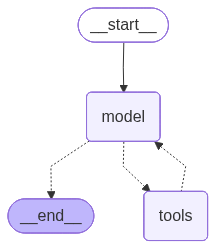

In [49]:
agent

In [50]:
async def fetch_image_as_b64(url: str) -> str:
    async with httpx.AsyncClient() as client:
        response = await client.get(url)
        response.raise_for_status()
        return base64.b64encode(response.content).decode("utf-8")

In [59]:
image_url = "https://plantvillage-production-new.s3.amazonaws.com/image/4120/file/default-9da3f2b050481374e22b39959b302b9d.jpg"
image_b64 = await fetch_image_as_b64(image_url)

In [60]:
image_b64

'...'

In [61]:
human = HumanMessage(
    content=[
        {
            "type": "text",
            "text": (
                "Whats wrong with my tomato plant?"
            ),
        },
        {
            "type": "image_url",
            "image_url": {
                "url": f"data:image/jpeg;base64,{image_b64}",
            },
        },
    ]
)

In [62]:
inputs = {
    "messages": [human],
    "image_url": image_url,
}

async for chunk in agent.astream(
    input=inputs,
    stream_mode="updates",
):
    for node_name, node_update in chunk.items():
        print(f"\nNode: {node_name}")
        print(f"Update: {node_update}")
        print("-" * 40)


Node: model
Update: {'messages': [AIMessage(content='', additional_kwargs={'function_call': {'name': 'leaf_detection', 'arguments': '{"labels": ["tomato leaf"]}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--04475059-cfae-4705-af5c-7c9f35abe1c8-0', tool_calls=[{'name': 'leaf_detection', 'args': {'labels': ['tomato leaf']}, 'id': '5c7fc202-bb5c-4a8b-90a0-bf5131447e24', 'type': 'tool_call'}], usage_metadata={'input_tokens': 1081, 'output_tokens': 196, 'total_tokens': 1277, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 180}})]}
----------------------------------------

Node: tools
Update: {'leaf_detections': [], 'messages': [ToolMessage(content='Detection Summary:\n\nDetailed Detections:\n', name='leaf_detection', id='9b1b3001-9a8d-4fd5-a447-192f282fa379', tool_call_id='5c7fc202-bb5c-4a8b-90